# Dataset creation (raw CSVs -> MongoDB)

End-to-end pipeline that:
1. Discovers raw `acc`/`gyr` CSVs under `data/`.
2. Pairs them by session key, merges on `Epoch` and applies a zero-phase Butterworth lowpass
3. Saves a static 6-axis time-series plot and a 3D acc/gyr scatter per session under `outputs/figures/`.
4. Inserts one merged document per session into the MongoDB collection from `config.yml`.

All heavy lifting lives in `utils.py` and `utils_visual.py` - this notebook is just orchestration.

> **Prerequisite:** MongoDB is running locally (`mongod` service up). On macOS: `brew services start mongodb-community`. On Windows: `net start MongoDB`. on Linux terminal to start MongoDB shel use the `mongosh`


## Setup

In [1]:
import os
from pathlib import Path
from collections import Counter

import yaml
from IPython.display import Image
from pathlib import Path

import utils
from utils import (
    discover_csvs, pair_acc_gyr, build_document,
    load_acc_csv, load_gyr_csv, merge_acc_gyr, apply_continuous_filter,
    mongo_connect, insert_documents,
)
import utils_visual

## Load configuration

In [2]:
BASE_DIR = Path(os.getcwd()).resolve()

config_path = BASE_DIR / "config.yml"
with open(config_path, encoding='utf-8') as f:
    config = yaml.safe_load(f)
DATA_DIR = (BASE_DIR / config["data_path"]).resolve()
FIGURES_DIR = (BASE_DIR / config["out_figures"]).resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FILTER_ORDER = config["filter"]["order"]
FILTER_WN = config["filter"]["wn"]
FILTER_TYPE = config["filter"]["type"]

print("data:    ", DATA_DIR)
print("figures: ", FIGURES_DIR)
print(f"filter:   Butterworth {FILTER_TYPE} order={FILTER_ORDER} wn={FILTER_WN}")

data:     D:\Documents\GitHub\social-media-gesture-recognition\data
figures:  D:\Documents\GitHub\social-media-gesture-recognition\outputs\figures
filter:   Butterworth lowpass order=4 wn=0.2


## 1. Discover & pair raw CSVs

Each session has **two** raw CSVs (`acc` + `gyr` separately). We pair them by their shared key `(gesture_id, finger, typing_style, hand, primary, user)` - the only field that differs is `sensor`.

In [3]:
csvs = discover_csvs(DATA_DIR)
print(f"Found {len(csvs)} CSV files")

#μπορει να γινει και αλλιως
pairs = list(pair_acc_gyr(csvs))
print(f"Paired {len(pairs)} sessions (expecting 27 = 9 gesture×variant × 3 users)")

# Quick sanity: balance per (gesture, user)
Counter((m["gesture_id"], m["user"]) for m, _, _ in pairs)

#return a dictionary --> look if it works
all_users = utils.ProcessingData(pairs)


Found 54 CSV files
Paired 27 sessions (expecting 27 = 9 gesture×variant × 3 users)


## 2. Load & Organize Data from Weareble

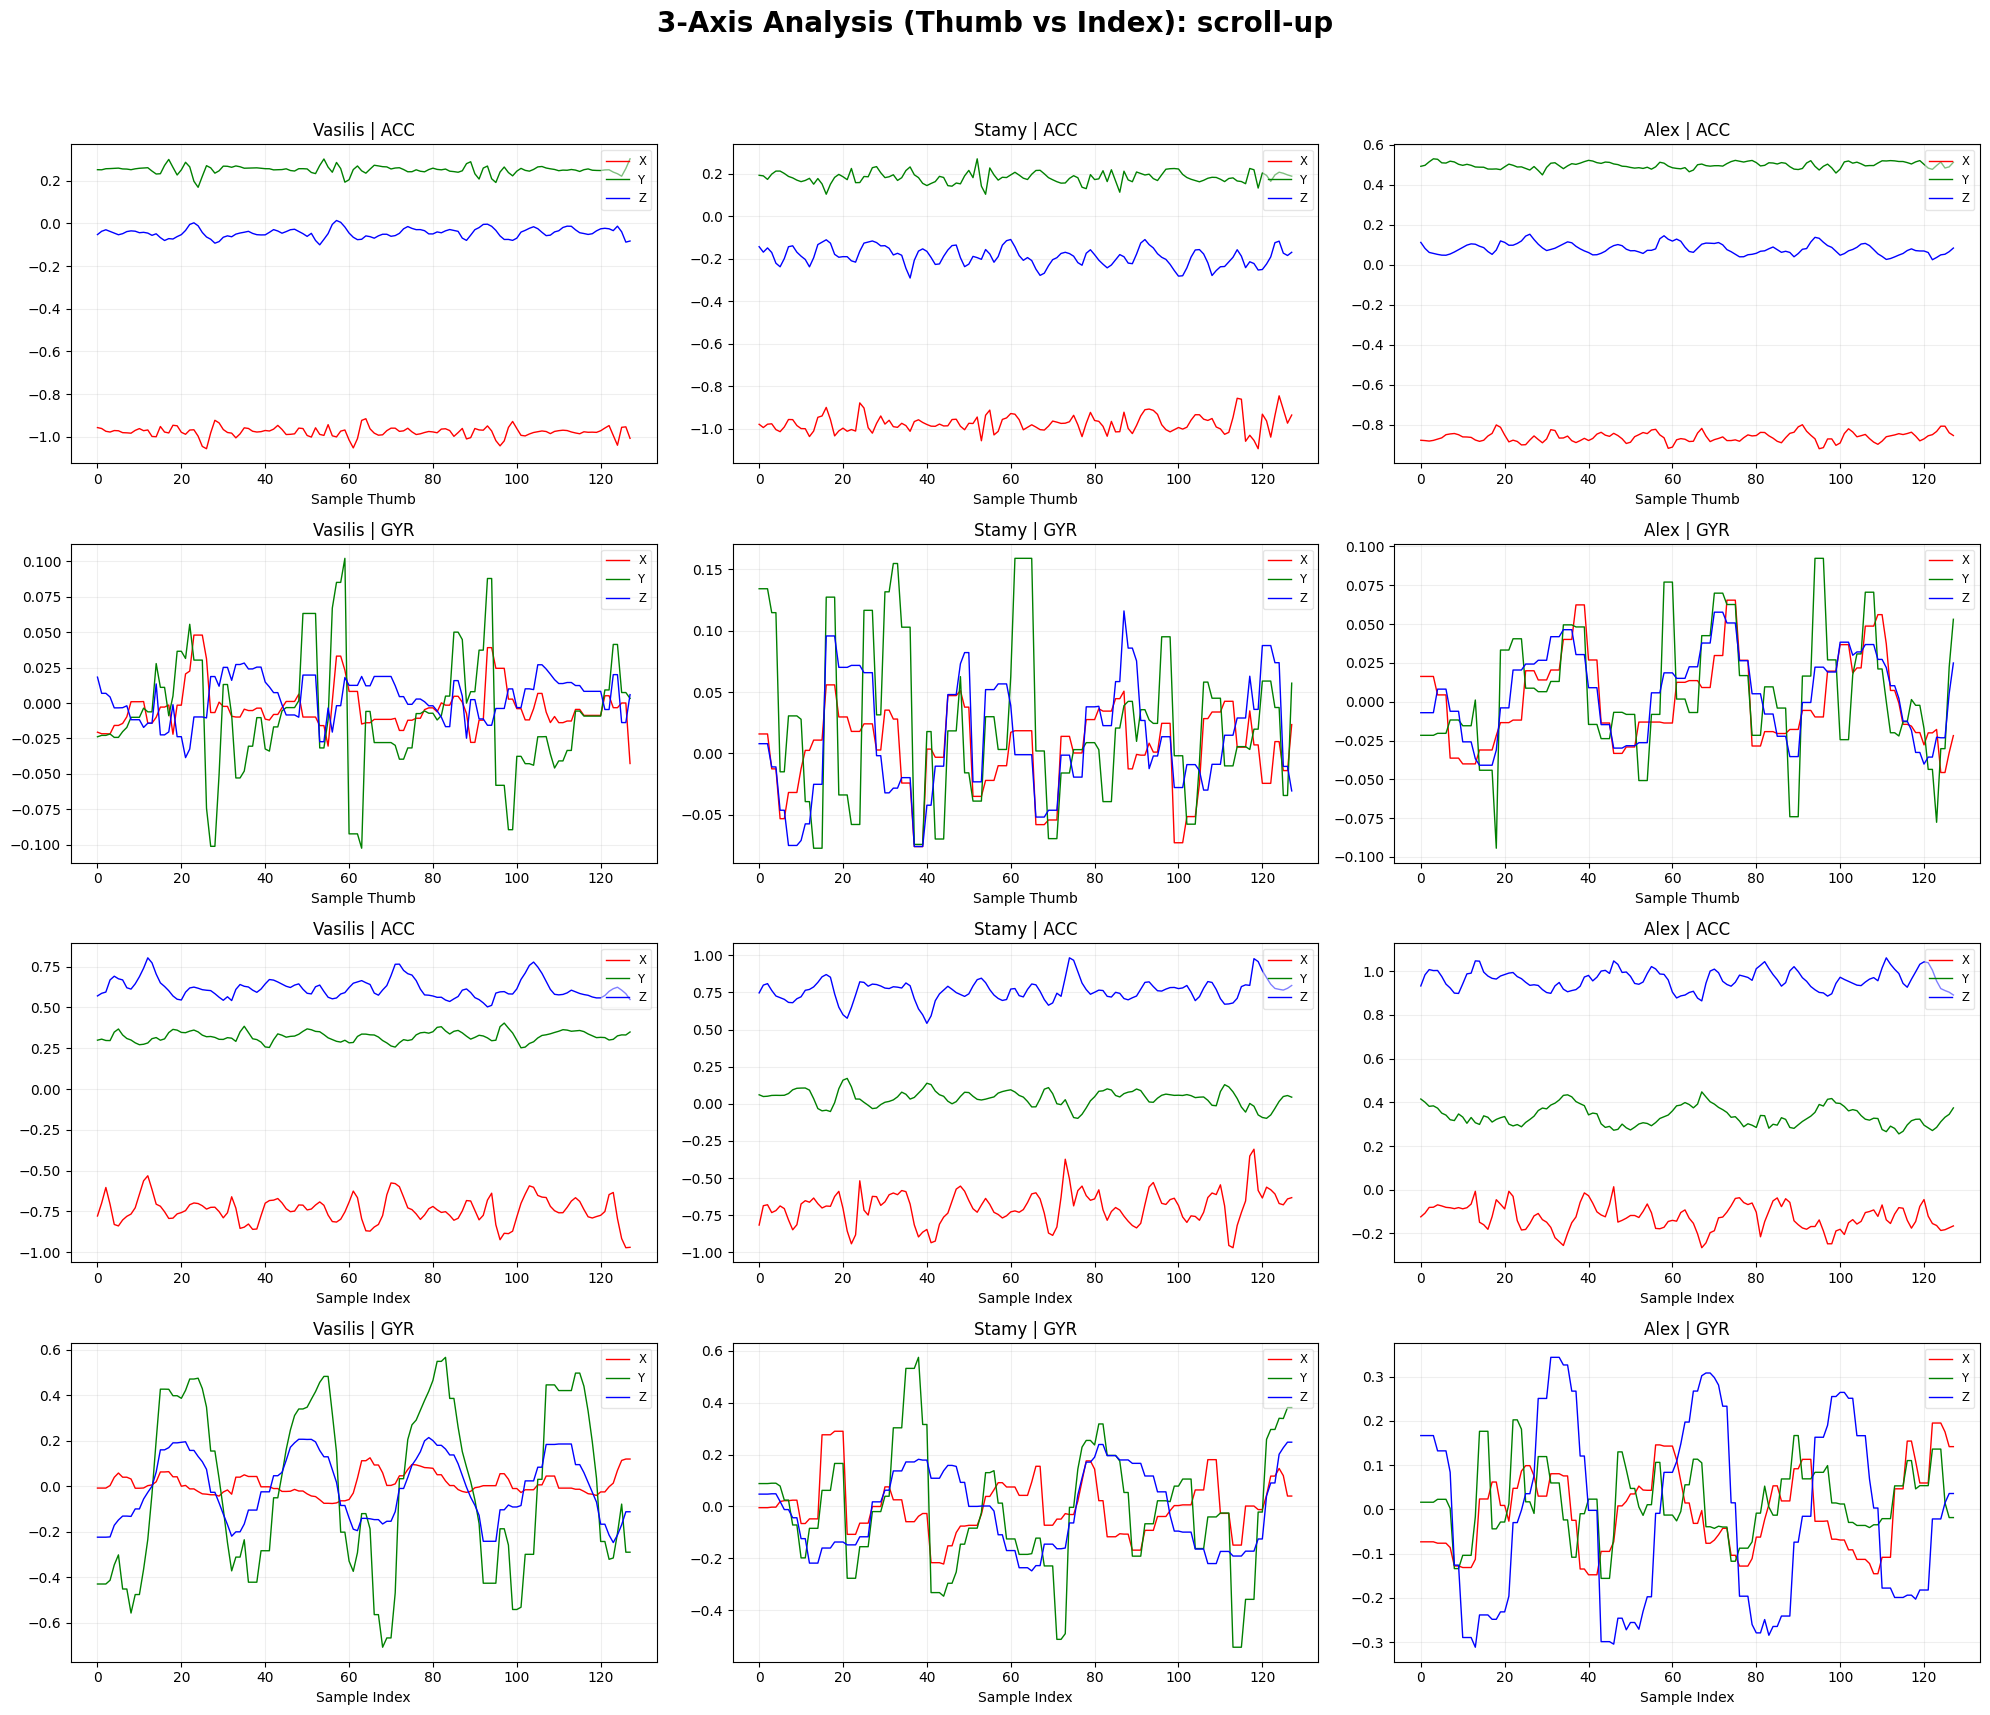

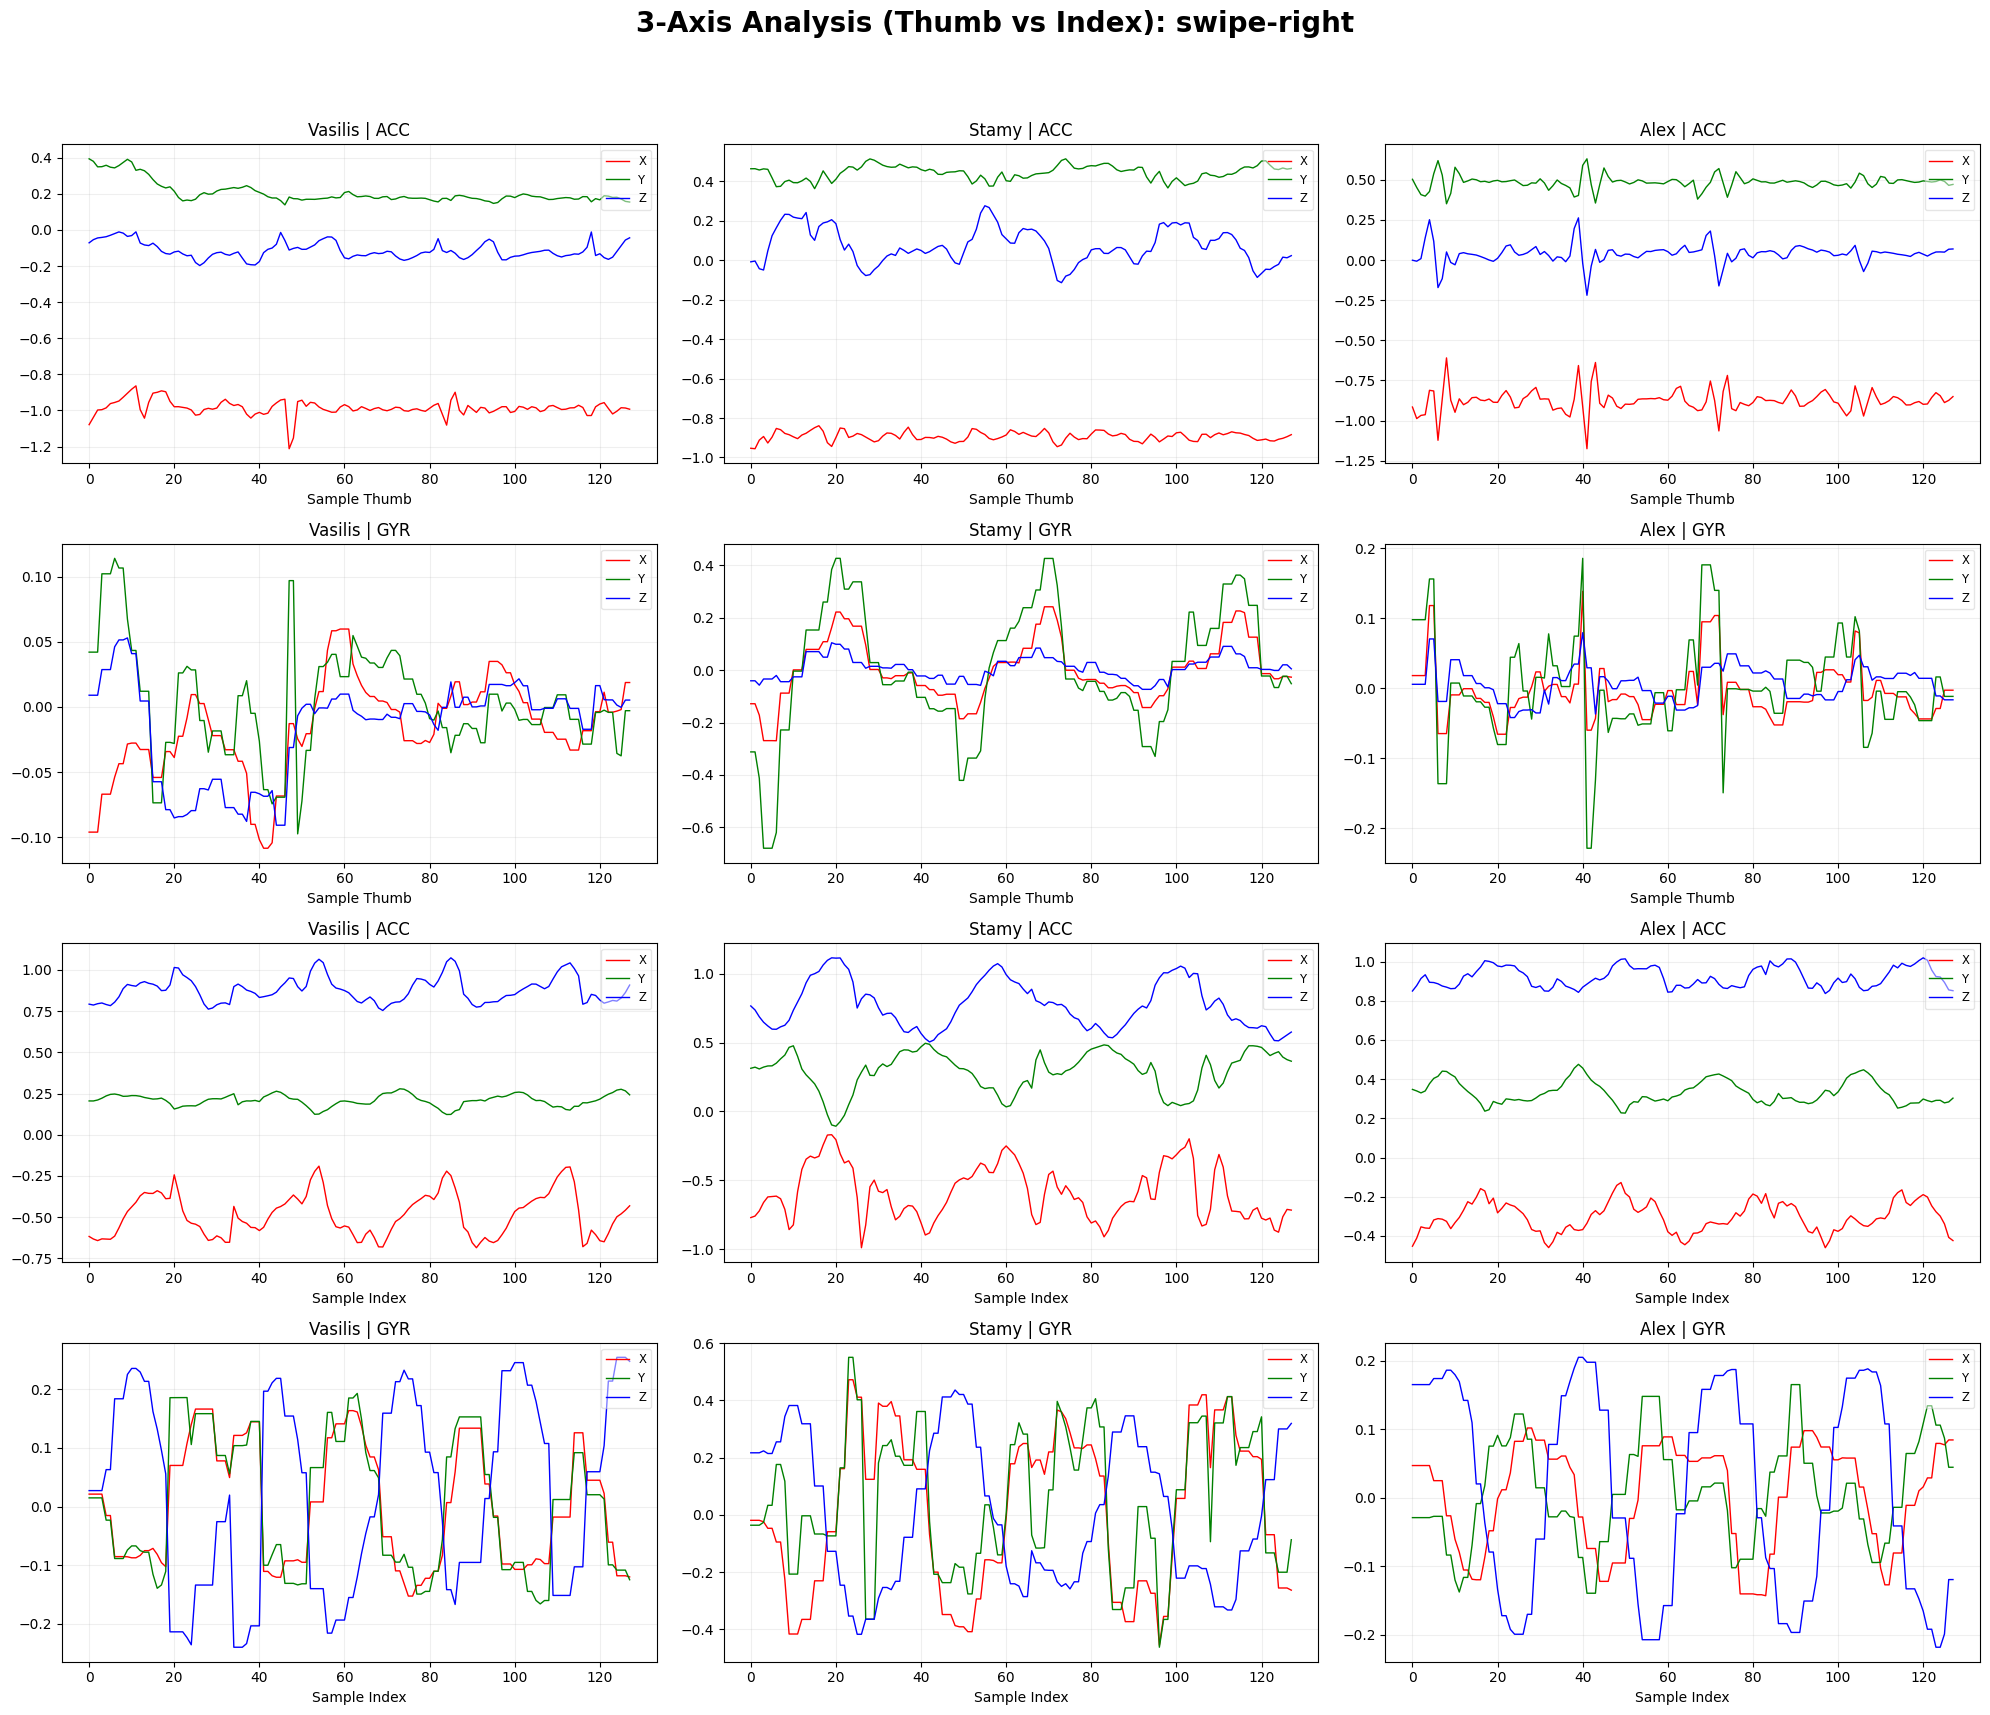

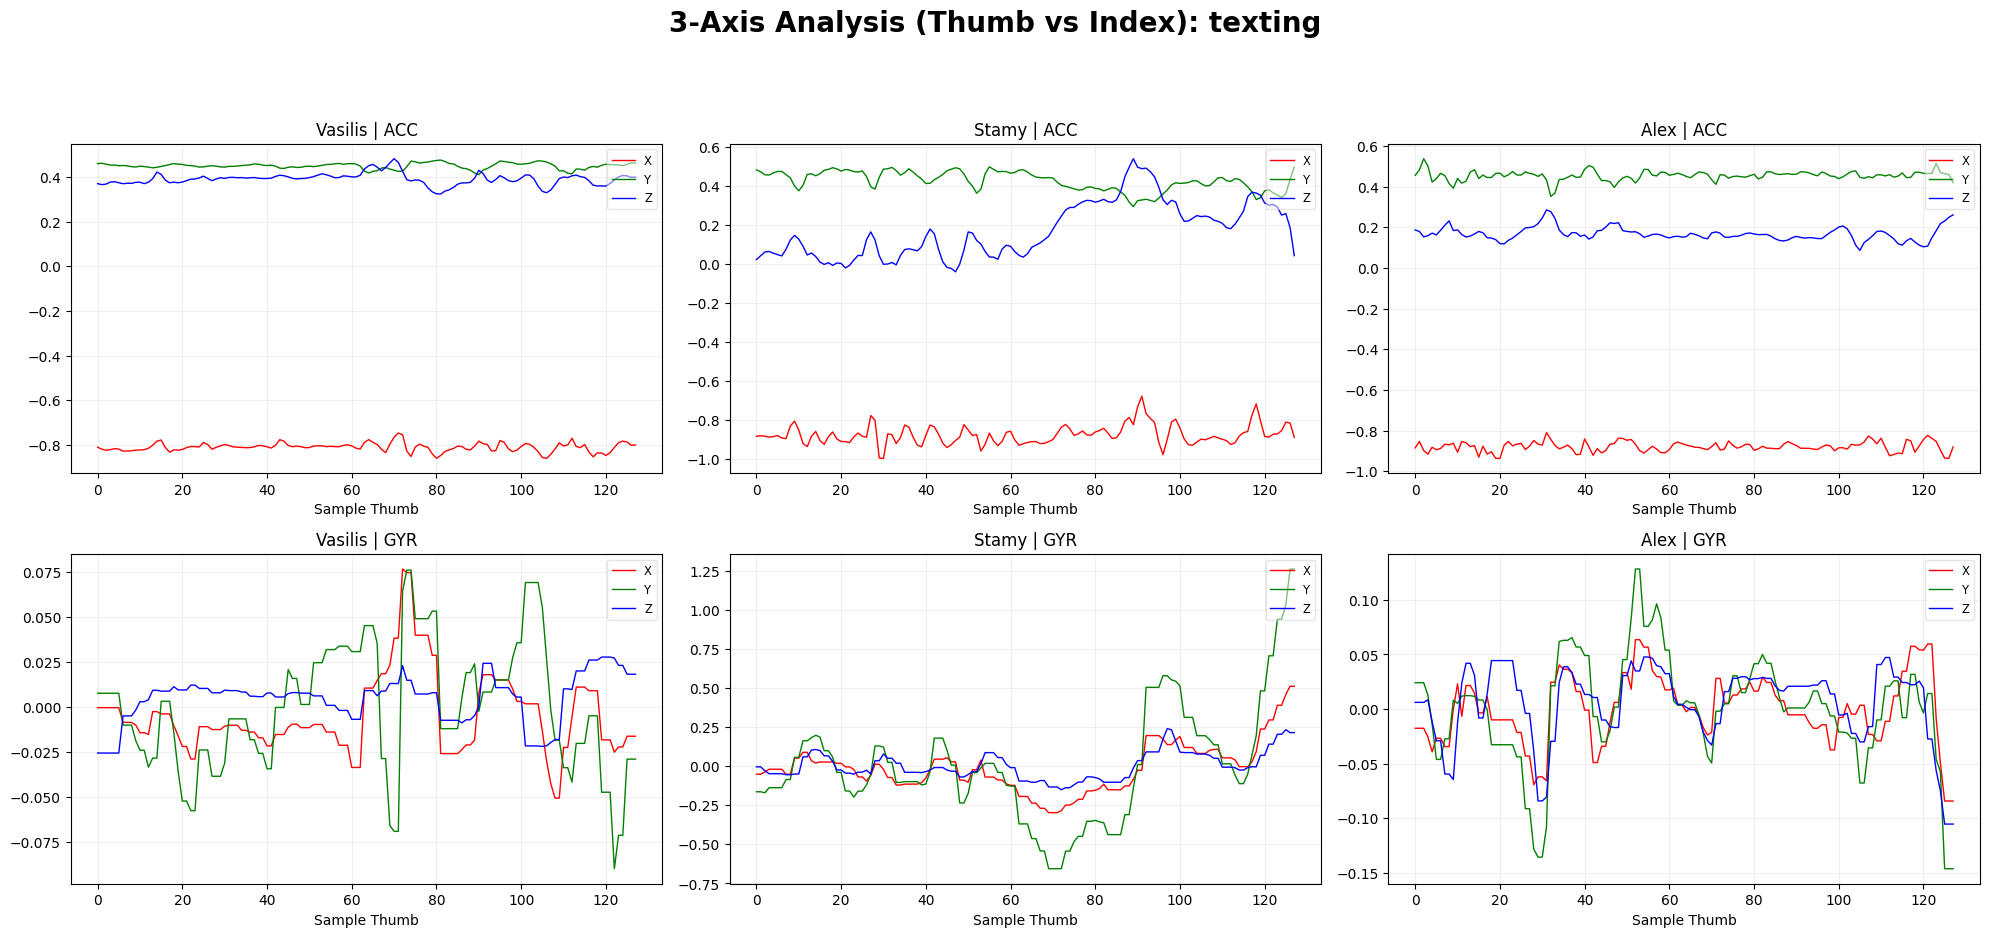

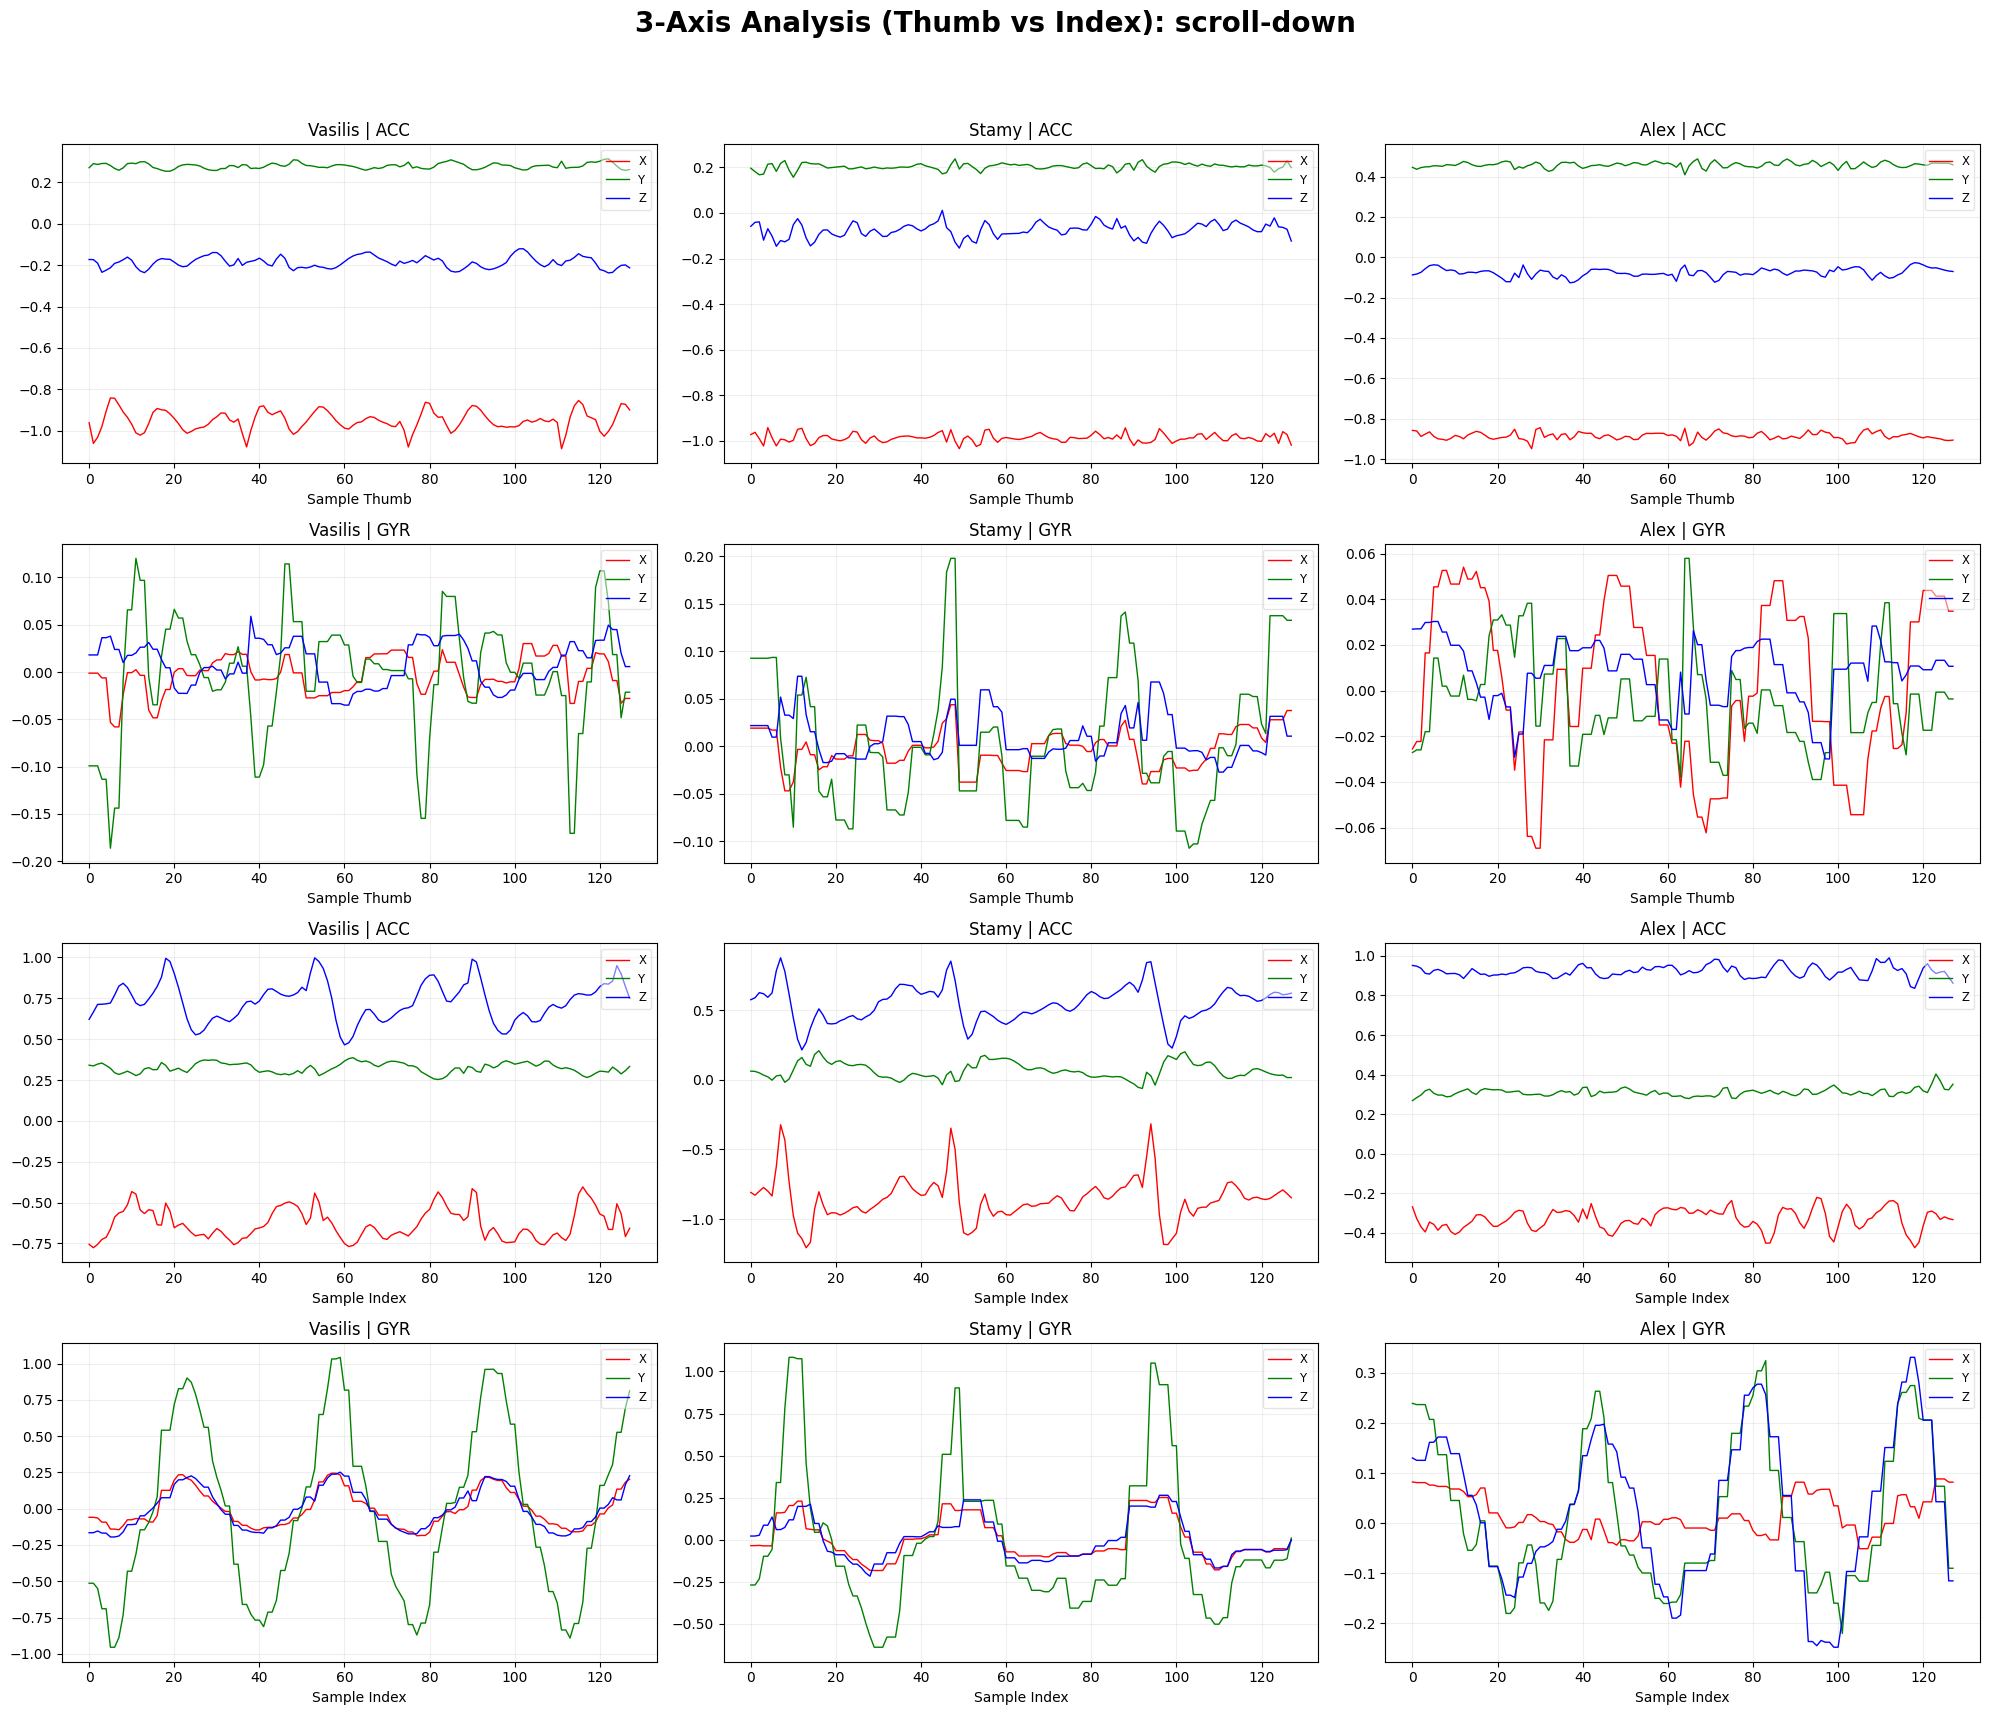

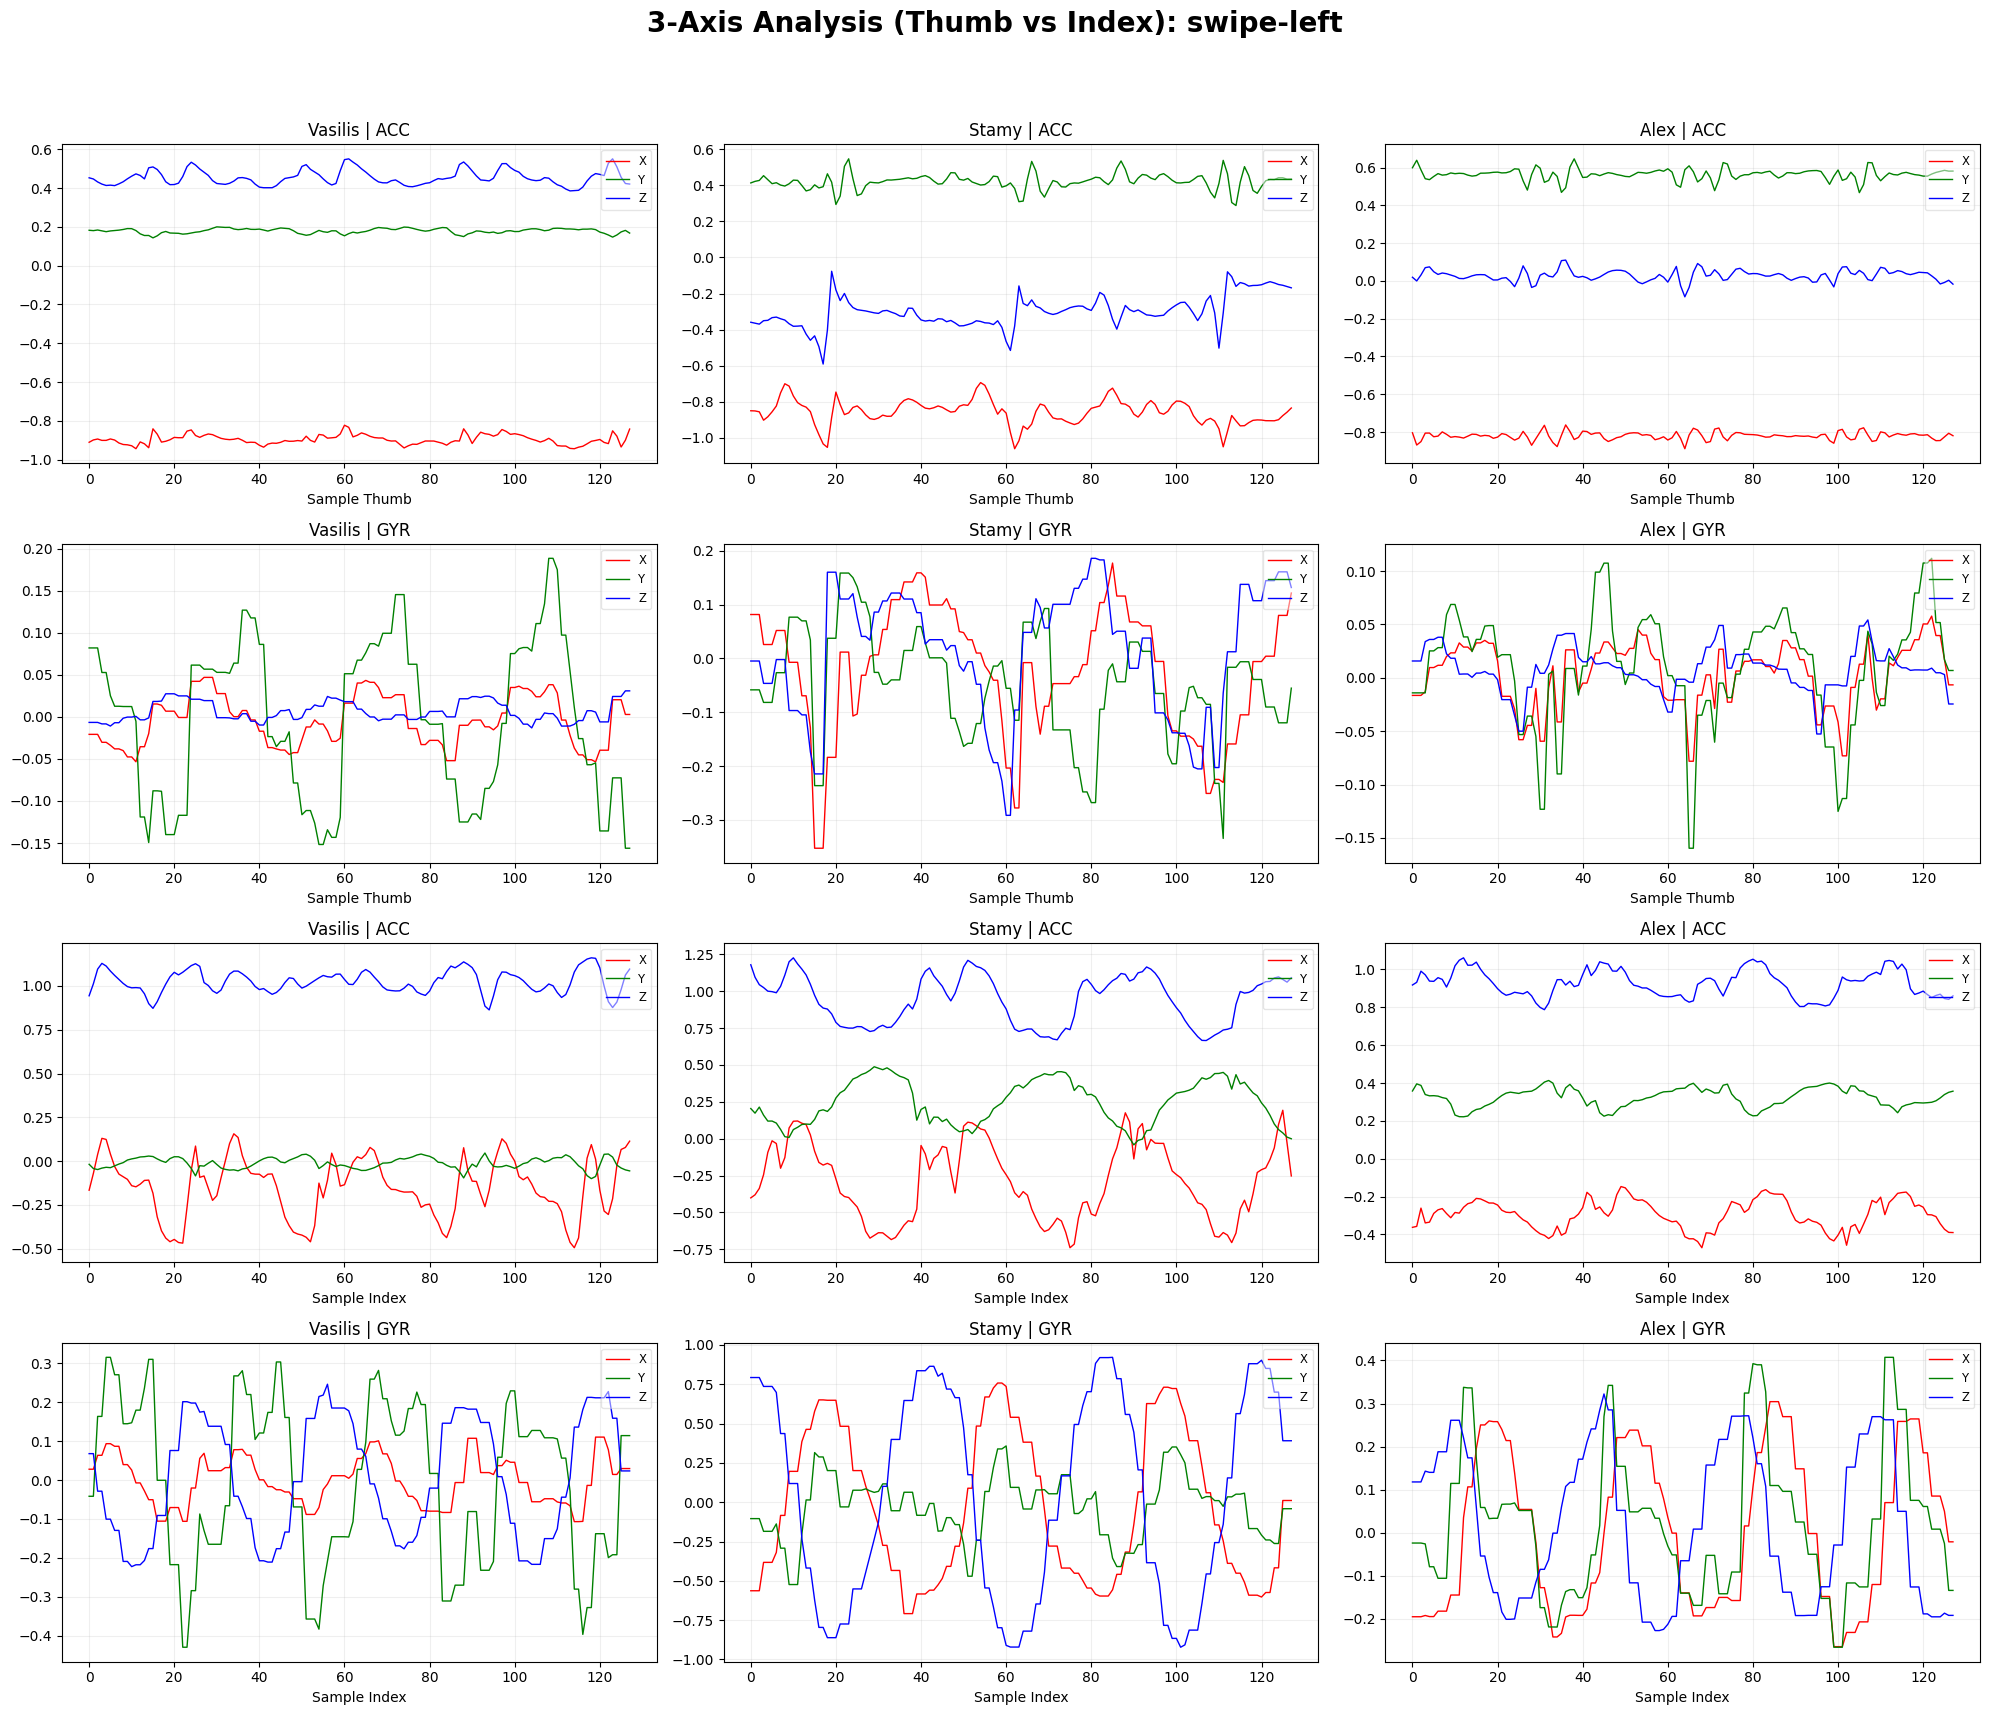

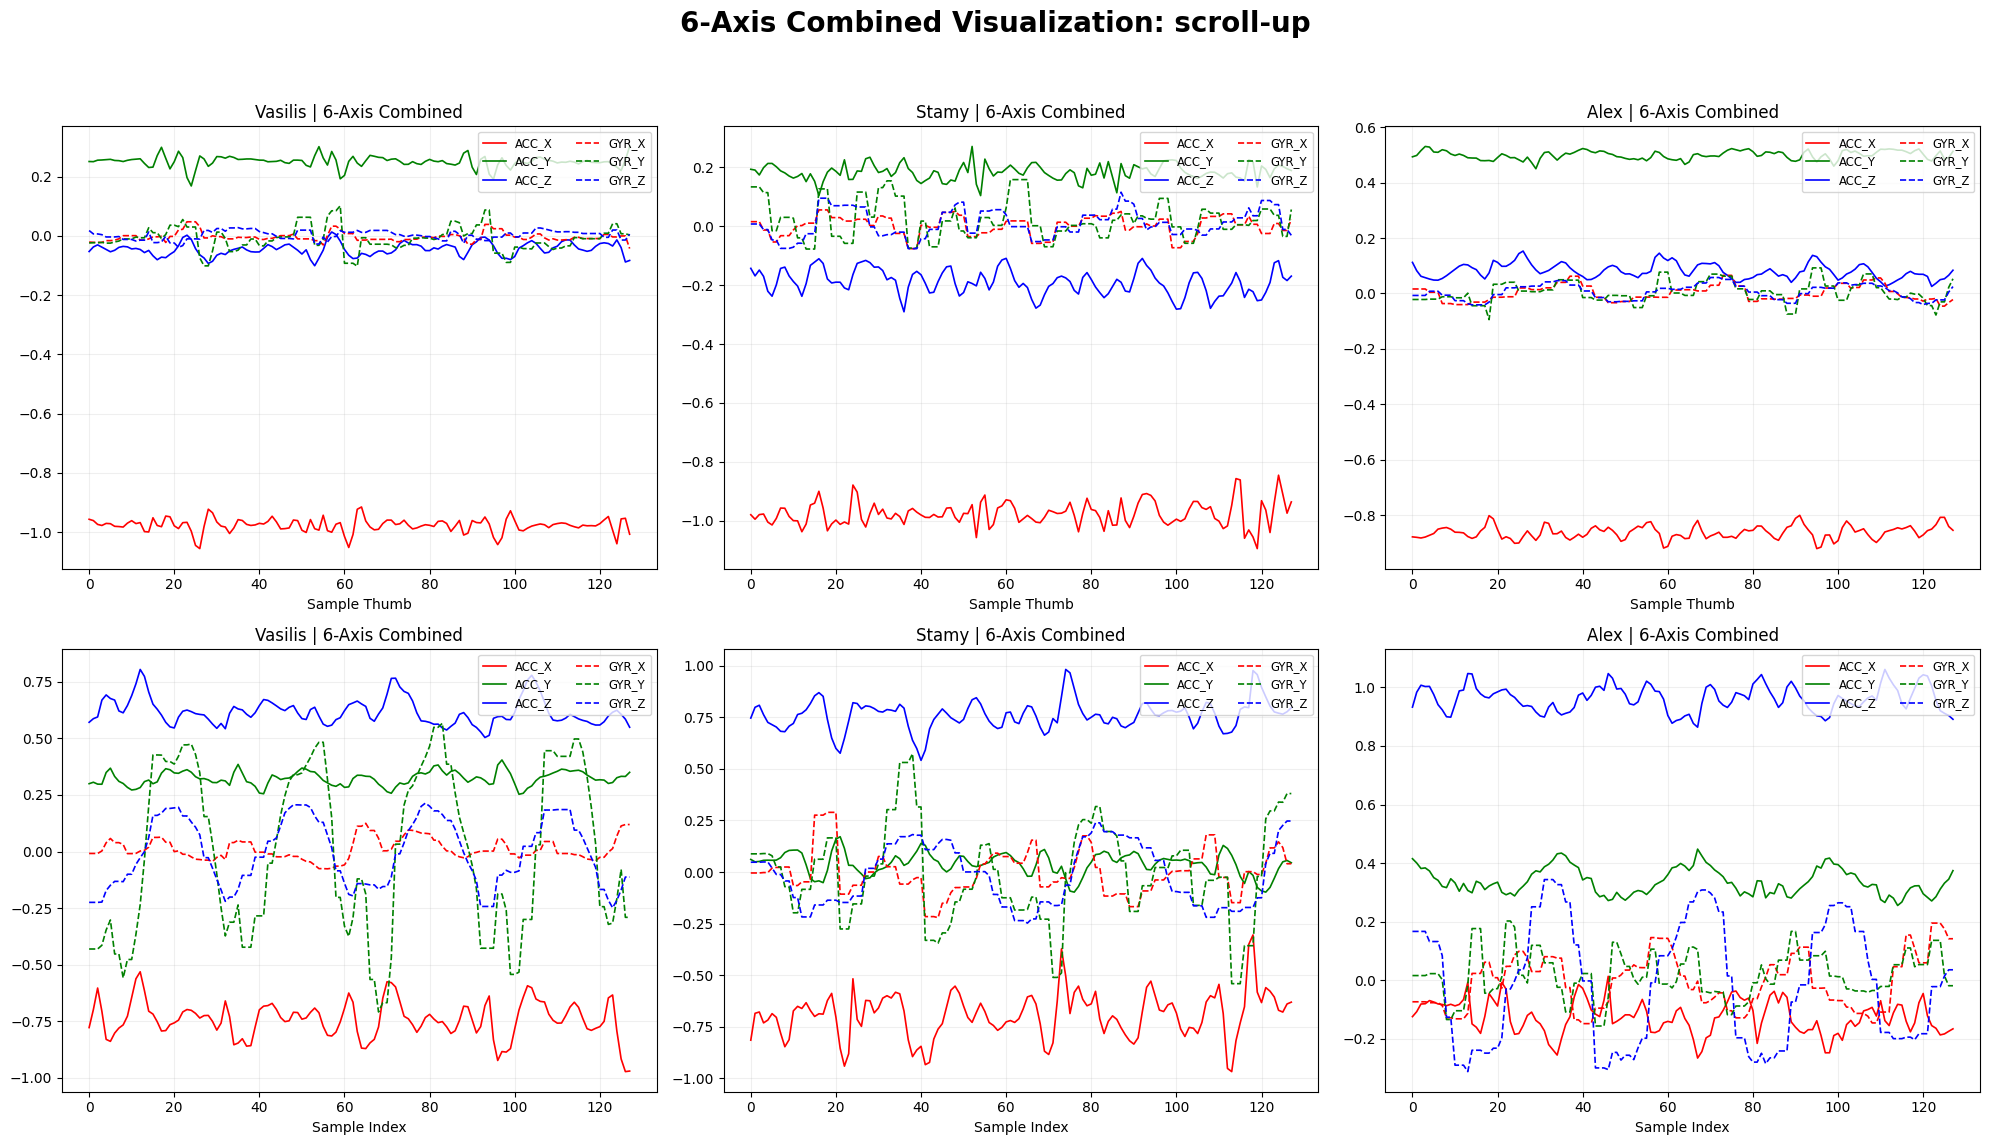

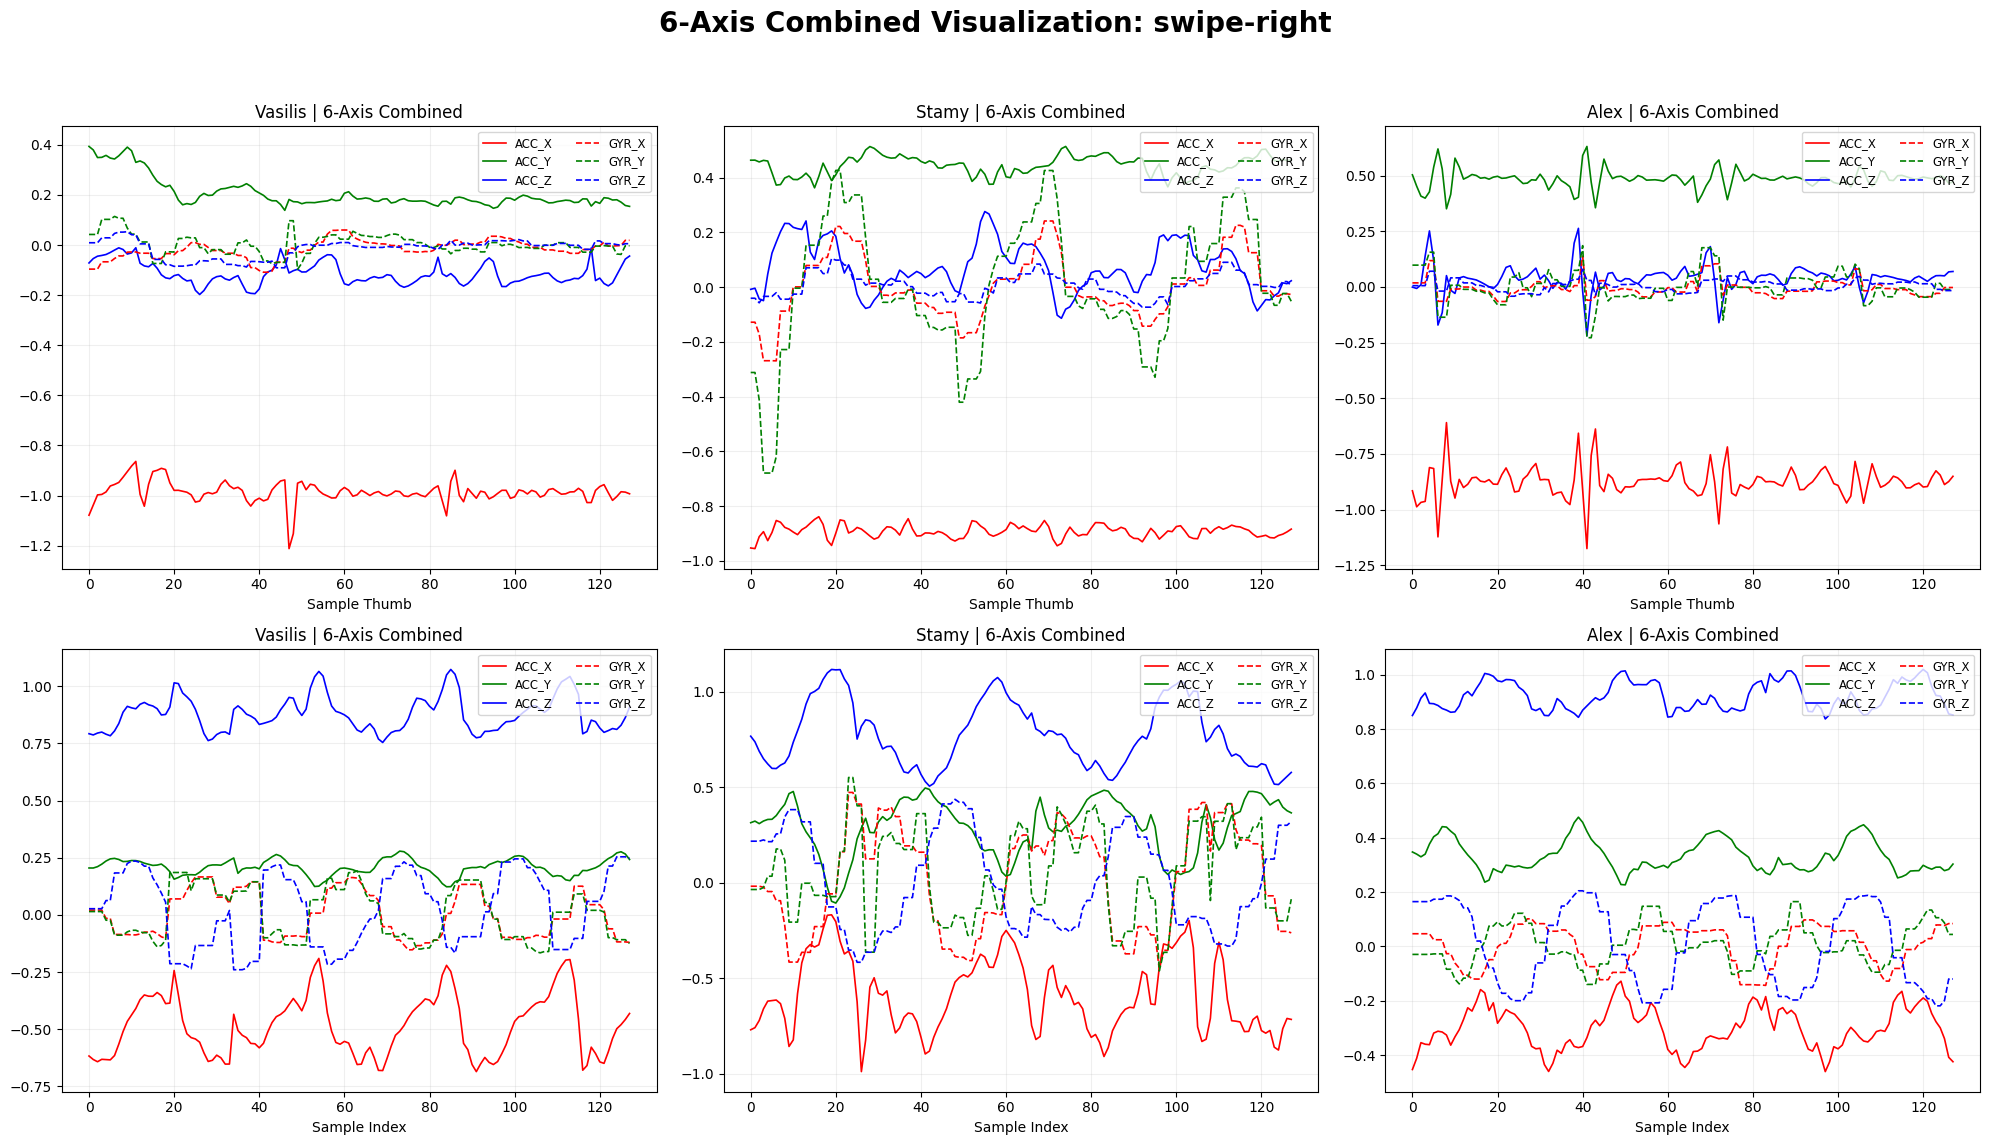

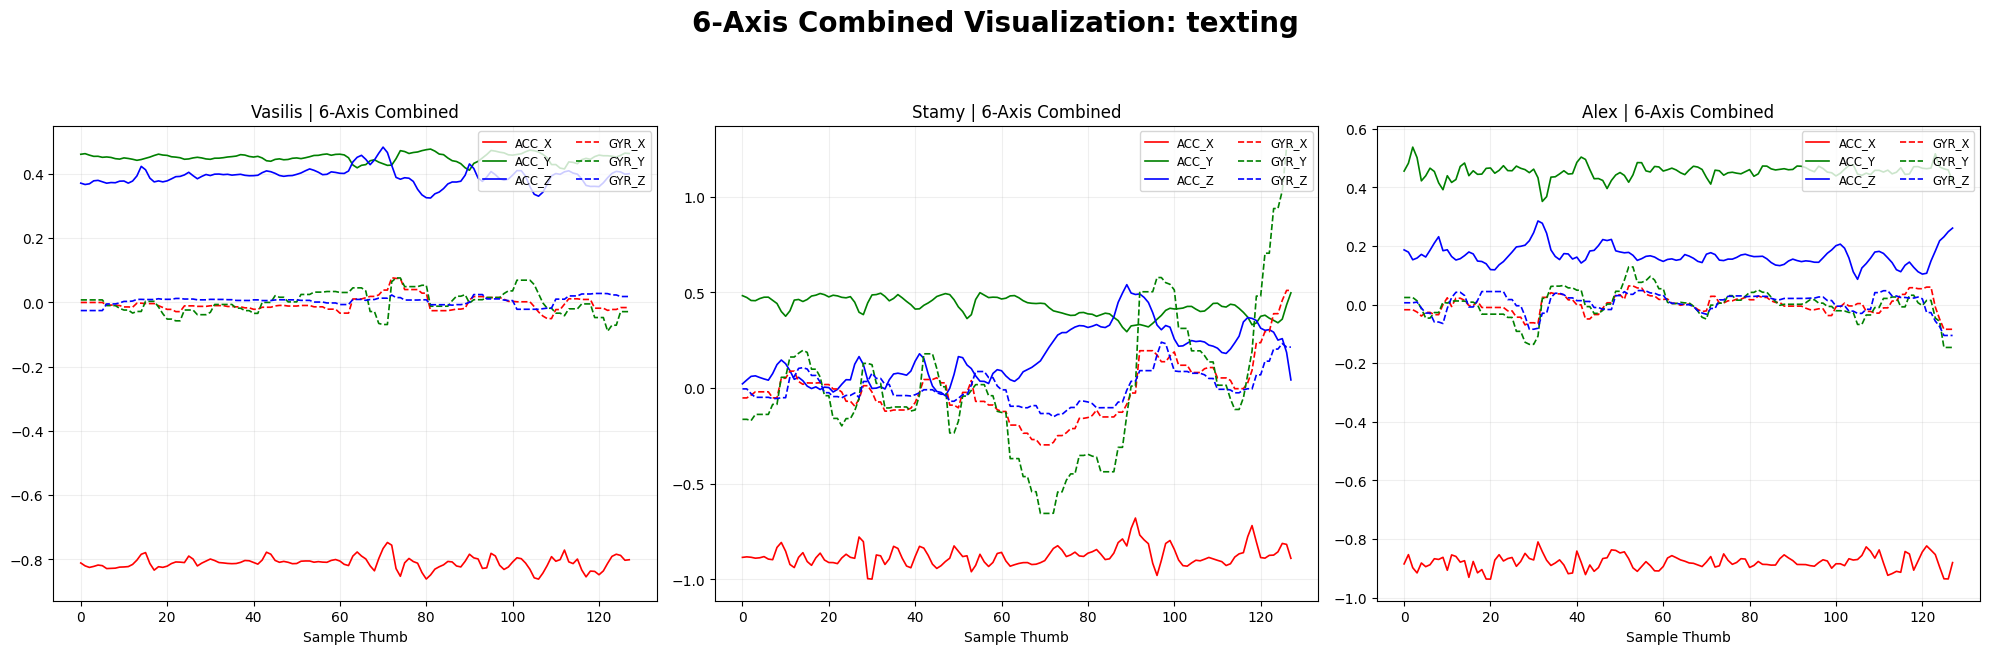

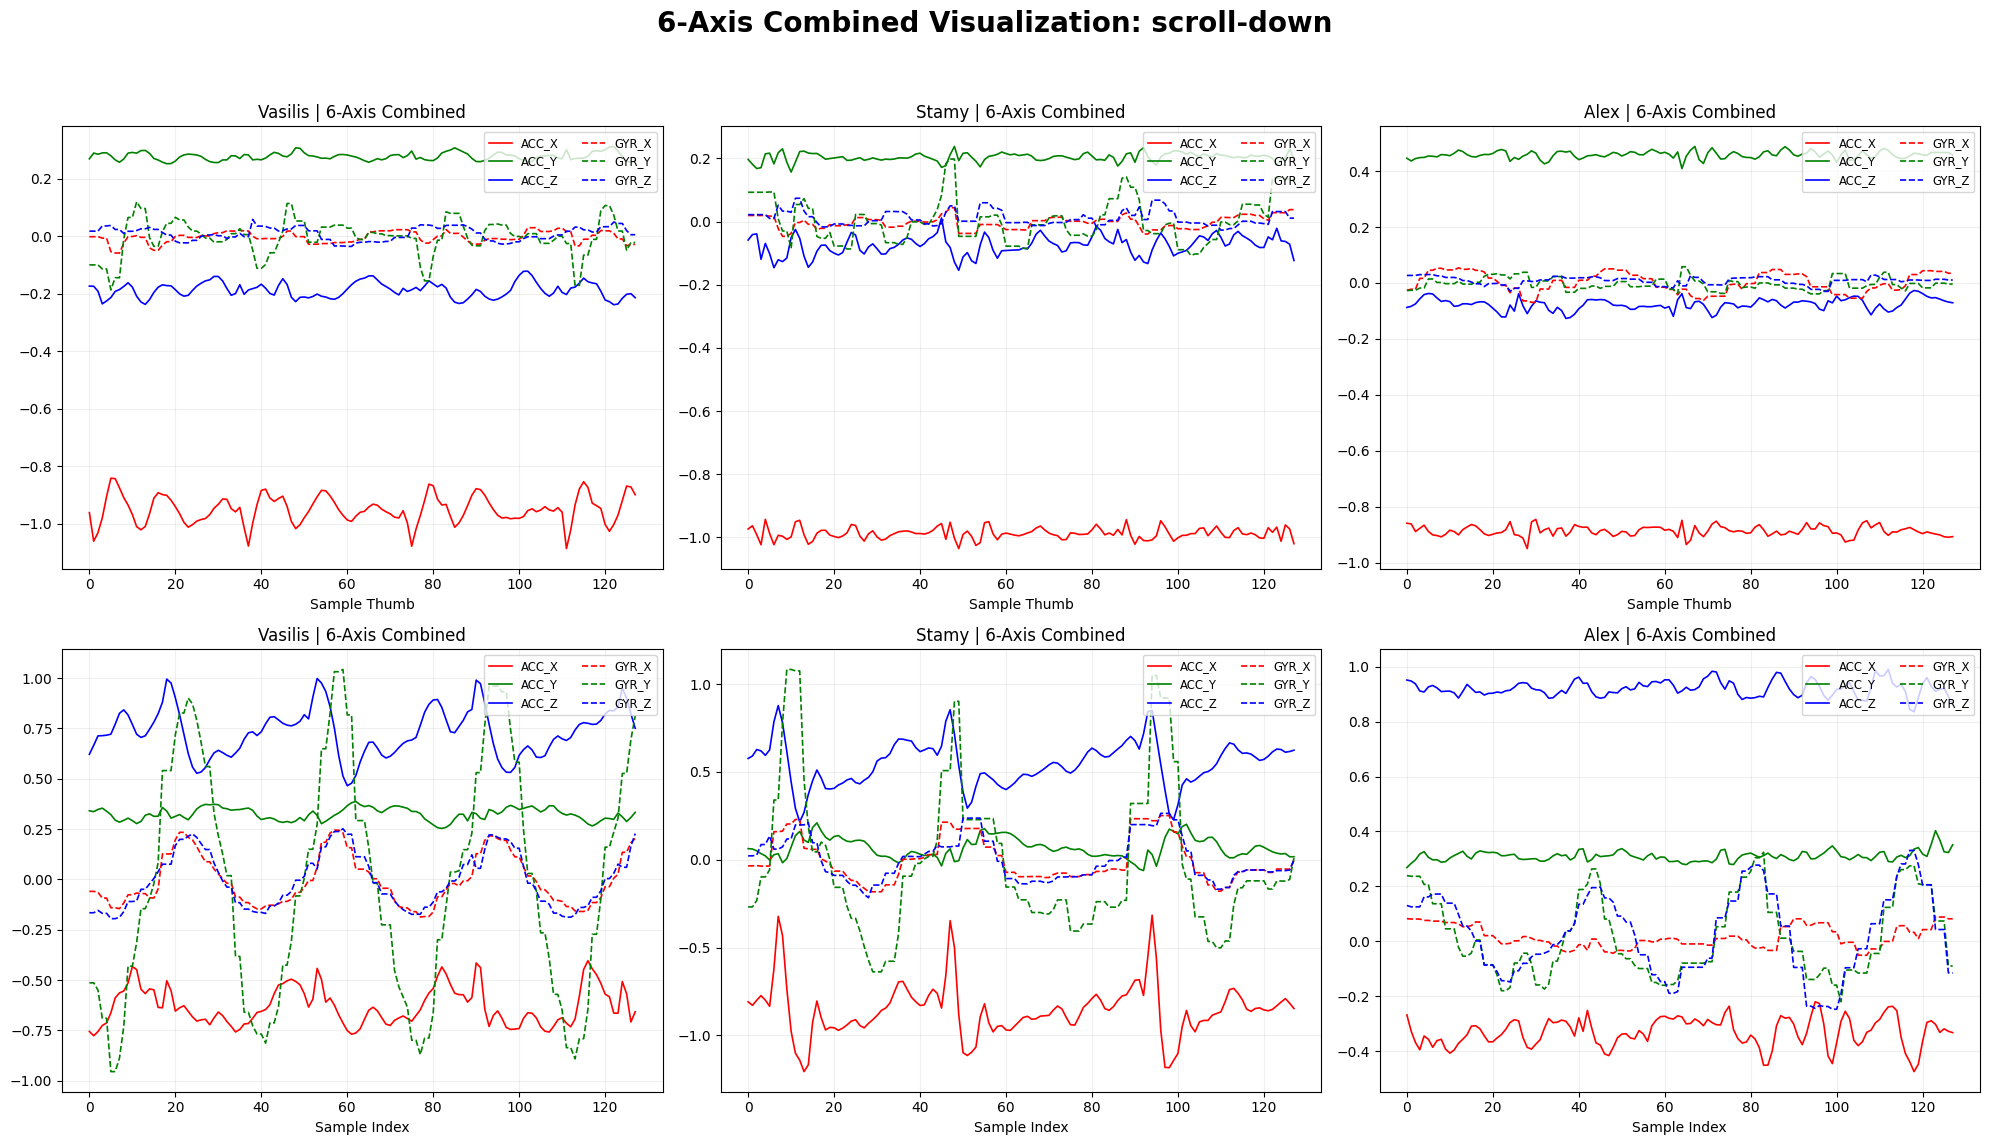

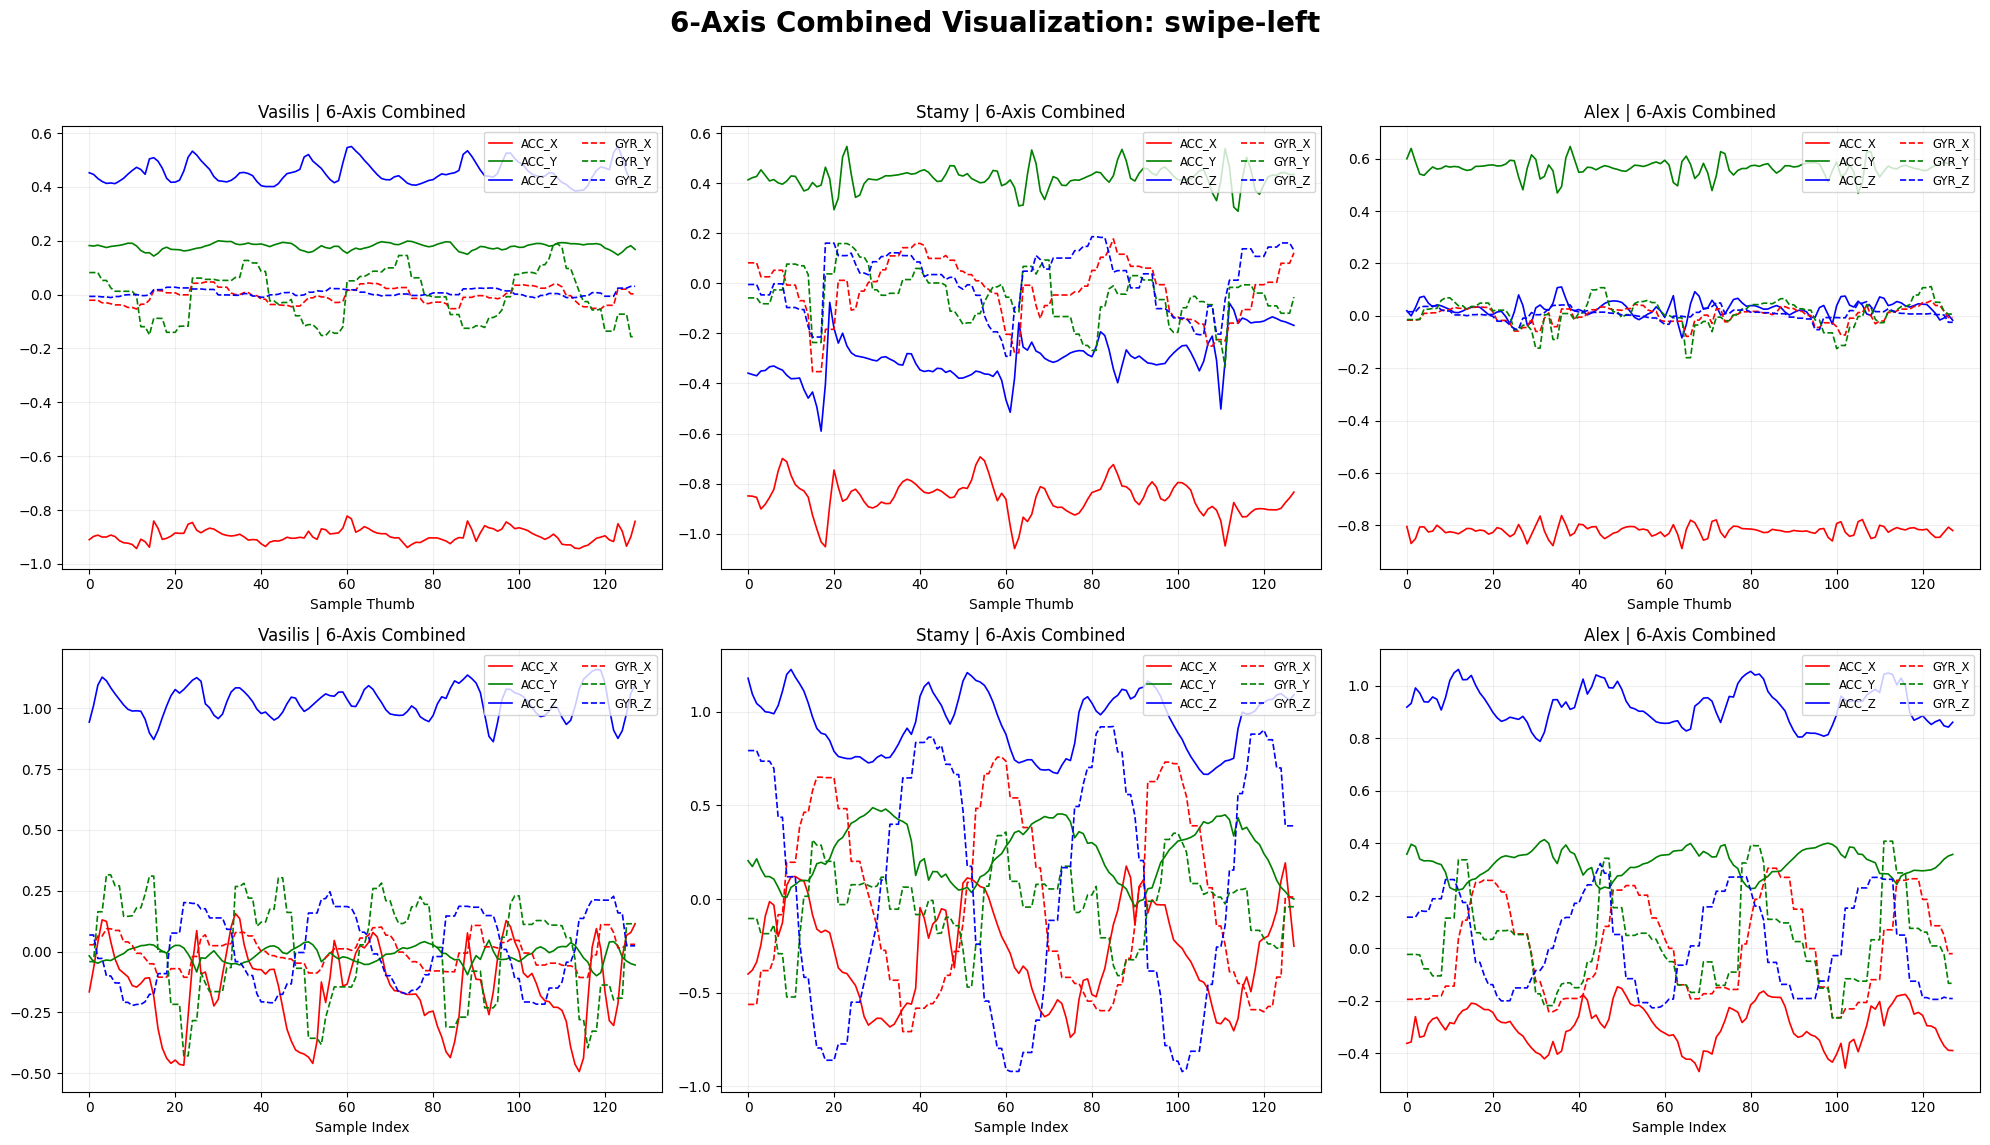

In [4]:
utils_visual.Plot_3axis(all_users, out_dir=FIGURES_DIR)
utils_visual.Plot_6axis(all_users, out_dir=FIGURES_DIR)

## 3. Load + merge + filter

Each pair is loaded, joined on `Epoch` with a 10 ms tolerance, and lowpass-filtered (Butterworth, order 4, fc=10 Hz @ fs=100 Hz). The result is one 6-axis DataFrame per session.


In [5]:
sessions = []
for meta, acc, gyr in pairs:
    merged = merge_acc_gyr(load_acc_csv(acc), load_gyr_csv(gyr))
    df = apply_continuous_filter(merged, order=FILTER_ORDER, wn=FILTER_WN)
    meta = {**meta, "acc_csv": acc.stem, "gyr_csv": gyr.stem}
    sessions.append((df, meta))
print(f"Loaded {len(sessions)} merged sessions")

# Quick sanity on the first one
df0, meta0 = sessions[0]
print(f"First session: {meta0['gesture_id']} / {meta0['finger']} / user={meta0['user']}  shape={df0.shape}")
df0.head()

Loaded 27 merged sessions
First session: scroll-down / index / user=a  shape=(15149, 7)


,Epoch,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
0,1777373011386,-0.301806,0.281225,0.945546,0.082004,0.241523,0.125887
1,1777373011388,-0.320319,0.289900,0.940239,0.081441,0.240239,0.128502
2,1777373011388,-0.338100,0.298072,0.934535,0.080648,0.235856,0.133975
3,1777373011388,-0.353063,0.304088,0.929184,0.079614,0.227057,0.141967
4,1777373011390,-0.364340,0.306906,0.924669,0.078332,0.212832,0.151261


## 4. Insert into MongoDB

`mongo_connect(reset=True)` clears existing documents in the collection (idempotent re-run) and creates a unique index on `session_id`.

In [6]:
coll = mongo_connect(uri=config["client"], db=config["db"], collection=config["col"], reset=config["reset_collection"])
print(f"Connected to {coll.full_name}")

docs = (build_document(df, meta) for df, meta in sessions)
n_ins = insert_documents(coll, docs)
print(f"Inserted {n_ins} documents")

Connected to IoTSocial.sensor_data
Inserted 27 documents


## 5. Verification

In [7]:
assert coll.count_documents({}) == len(sessions), "Document count mismatch"

# Count per gesture
from collections import Counter
gestures = Counter(d["gesture_id"] for d in coll.find({}, {"gesture_id": 1}))
print("Per gesture:", dict(gestures))

# Inspect one document (without the heavy `data` field)
sample = coll.find_one({}, {"data": 0})
sample

Per gesture: {'scroll-down': 6, 'scroll-up': 6, 'swipe-left': 6, 'swipe-right': 6, 'texting': 3}


{'_id': ObjectId('6a01cfb970315b49514bb198'),
 'session_id': '60d6348319b7e63681ed043c',
 'gesture_id': 'scroll-down',
 'finger': 'index',
 'typing_style': 'na',
 'hand': 0,
 'sr': 100,
 'sensor': 'AccGyr',
 'primary': 0,
 'spontaneous': 0,
 'user': 'a',
 'datetime': datetime.datetime(2026, 5, 11, 12, 46, 49, 259000)}